# Step 7: Hyperparameter Tuning
### DI 501 Term Project | Eda Yilmaz

**Goal:**  
Tune Decision Tree and Random Forest hyperparameters to reduce overfitting and improve per-cluster rRMSE.

**Why tuning is needed:**  
Default Decision Tree (unlimited depth) overfits severely — especially on Cluster 2 which has only ~1,381 training observations after excluding Brazil.  
Default Random Forest also benefits from depth constraints.

**Method:** GridSearchCV with 5-fold cross-validation, scoring = negative RMSE  
**Data:** 36 countries (BR + US excluded), same as Step 6

---

## 1. Load Data & Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 120

SELECTED_FEATURES = ['heat_stress_days', 'prec_gs']
TARGET            = 'detrended_yield'
CLUSTERS          = [0, 1, 2]
CLUSTER_COLORS    = {0: '#e07b39', 1: '#3b82c4', 2: '#5aad5a'}
ML_EXCLUDE        = ['BR', 'US']

df_all = pd.read_csv('./master_global_ml_dataset.csv').dropna(
    subset=SELECTED_FEATURES + [TARGET]
)
df = df_all[~df_all['country'].isin(ML_EXCLUDE)].copy()

print(f'ML training dataset: {len(df):,} obs | {df["country"].nunique()} countries')
print('Obs per cluster:')
print(df.groupby('cluster').size().to_string())

ML training dataset: 30,278 obs | 36 countries
Obs per cluster:
cluster
0     8754
1    20143
2     1381


---
## 2. Evaluation Function (same as Step 6)

In [11]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def rrmse(y_true, y_pred, mean_yield):
    return (rmse(y_true, y_pred) / mean_yield) * 100

def evaluate_model(model, df, features, target, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    X = df[features].values
    y = df[target].values
    all_preds = np.zeros(len(df))
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)
        model.fit(X_train, y_train)
        all_preds[test_idx] = model.predict(X_test)
    df = df.copy()
    df['y_pred'] = all_preds
    results = []
    for c in CLUSTERS:
        sub = df[df['cluster'] == c]
        if len(sub) == 0:
            continue
        mean_yield = sub['yield'].mean()
        results.append({
            'Cluster':     f'Cluster {c}',
            'N':           len(sub),
            'RMSE (t/ha)': round(rmse(sub[target].values, sub['y_pred'].values), 3),
            'rRMSE (%)':   round(rrmse(sub[target].values, sub['y_pred'].values, mean_yield), 2)
        })
    return pd.DataFrame(results), df

print('Evaluation functions defined.')

Evaluation functions defined.


---
## 3. Hyperparameter Tuning — Decision Tree

The most critical parameter is `max_depth` — unlimited depth causes severe overfitting.  
We also tune `min_samples_leaf` to enforce minimum region coverage per leaf.

In [12]:
X = df[SELECTED_FEATURES].values
y = df[TARGET].values

scaler_gs = StandardScaler()
X_scaled = scaler_gs.fit_transform(X)

dt_param_grid = {
    'max_depth':         [2, 3, 4, 5, 6, 8],
    'min_samples_leaf':  [5, 10, 20, 50],
    'min_samples_split': [5, 10, 20]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
dt_grid.fit(X_scaled, y)

print('DECISION TREE — Best hyperparameters:')
print(f'  {dt_grid.best_params_}')
print(f'  Best CV RMSE: {-dt_grid.best_score_:.4f} t/ha')

DECISION TREE — Best hyperparameters:
  {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 5}
  Best CV RMSE: 1.0620 t/ha


---
## 4. Hyperparameter Tuning — Random Forest

In [13]:
rf_param_grid = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [3, 5, 8, None],
    'min_samples_leaf': [5, 10, 20]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_scaled, y)

print('RANDOM FOREST — Best hyperparameters:')
print(f'  {rf_grid.best_params_}')
print(f'  Best CV RMSE: {-rf_grid.best_score_:.4f} t/ha')

RANDOM FOREST — Best hyperparameters:
  {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 200}
  Best CV RMSE: 1.0579 t/ha


---
## 5. Evaluate Tuned Models Per Cluster

In [14]:
dt_tuned = DecisionTreeRegressor(random_state=42, **dt_grid.best_params_)
rf_tuned  = RandomForestRegressor(random_state=42, **rf_grid.best_params_)

dt_tuned_results, _ = evaluate_model(dt_tuned, df, SELECTED_FEATURES, TARGET)
rf_tuned_results, _ = evaluate_model(rf_tuned, df, SELECTED_FEATURES, TARGET)

# Naive baseline
naive_results = []
for c in CLUSTERS:
    sub = df[df['cluster'] == c]
    if len(sub) == 0: continue
    mean_yield = sub['yield'].mean()
    naive_results.append({
        'Cluster':     f'Cluster {c}',
        'N':           len(sub),
        'RMSE (t/ha)': round(rmse(sub[TARGET].values, np.zeros(len(sub))), 3),
        'rRMSE (%)':   round(rrmse(sub[TARGET].values, np.zeros(len(sub)), mean_yield), 2)
    })
naive_df = pd.DataFrame(naive_results)

print('NAIVE BASELINE:')
print(naive_df.to_string(index=False))
print()
print('TUNED DECISION TREE:')
print(dt_tuned_results.to_string(index=False))
print()
print('TUNED RANDOM FOREST:')
print(rf_tuned_results.to_string(index=False))

NAIVE BASELINE:
  Cluster     N  RMSE (t/ha)  rRMSE (%)
Cluster 0  8754        1.184      25.34
Cluster 1 20143        1.058      18.74
Cluster 2  1381        0.563      31.56

TUNED DECISION TREE:
  Cluster     N  RMSE (t/ha)  rRMSE (%)
Cluster 0  8754        1.124      24.06
Cluster 1 20143        1.042      18.44
Cluster 2  1381        0.591      33.14

TUNED RANDOM FOREST:
  Cluster     N  RMSE (t/ha)  rRMSE (%)
Cluster 0  8754        1.118      23.95
Cluster 1 20143        1.038      18.37
Cluster 2  1381        0.593      33.27


---
## 6. Full Comparison: Naive vs Default vs Tuned

In [15]:
dt_default_results, _ = evaluate_model(DecisionTreeRegressor(random_state=42), df, SELECTED_FEATURES, TARGET)
rf_default_results, _ = evaluate_model(RandomForestRegressor(random_state=42),  df, SELECTED_FEATURES, TARGET)

print('FULL COMPARISON — rRMSE (%) per cluster')
print()
print(f'{"Cluster":<12} {"Naive":>8} {"DT default":>12} {"DT tuned":>10} {"RF default":>12} {"RF tuned":>10}')
print('-' * 68)
for i, c in enumerate(CLUSTERS):
    naive_r  = naive_df.iloc[i]['rRMSE (%)']
    dt_def_r = dt_default_results.iloc[i]['rRMSE (%)']
    dt_tun_r = dt_tuned_results.iloc[i]['rRMSE (%)']
    rf_def_r = rf_default_results.iloc[i]['rRMSE (%)']
    rf_tun_r = rf_tuned_results.iloc[i]['rRMSE (%)']
    def mark(v): return f'{v:.1f}%*' if v < naive_r else f'{v:.1f}%'
    print(f'Cluster {c}   {naive_r:>7.1f}% {mark(dt_def_r):>12} {mark(dt_tun_r):>10} {mark(rf_def_r):>12} {mark(rf_tun_r):>10}')
print()
print('* = beats naive baseline')

FULL COMPARISON — rRMSE (%) per cluster

Cluster         Naive   DT default   DT tuned   RF default   RF tuned
--------------------------------------------------------------------
Cluster 0      25.3%        32.3%     24.1%*       25.3%*     23.9%*
Cluster 1      18.7%        26.4%     18.4%*        20.6%     18.4%*
Cluster 2      31.6%        58.8%      33.1%        43.3%      33.3%

* = beats naive baseline


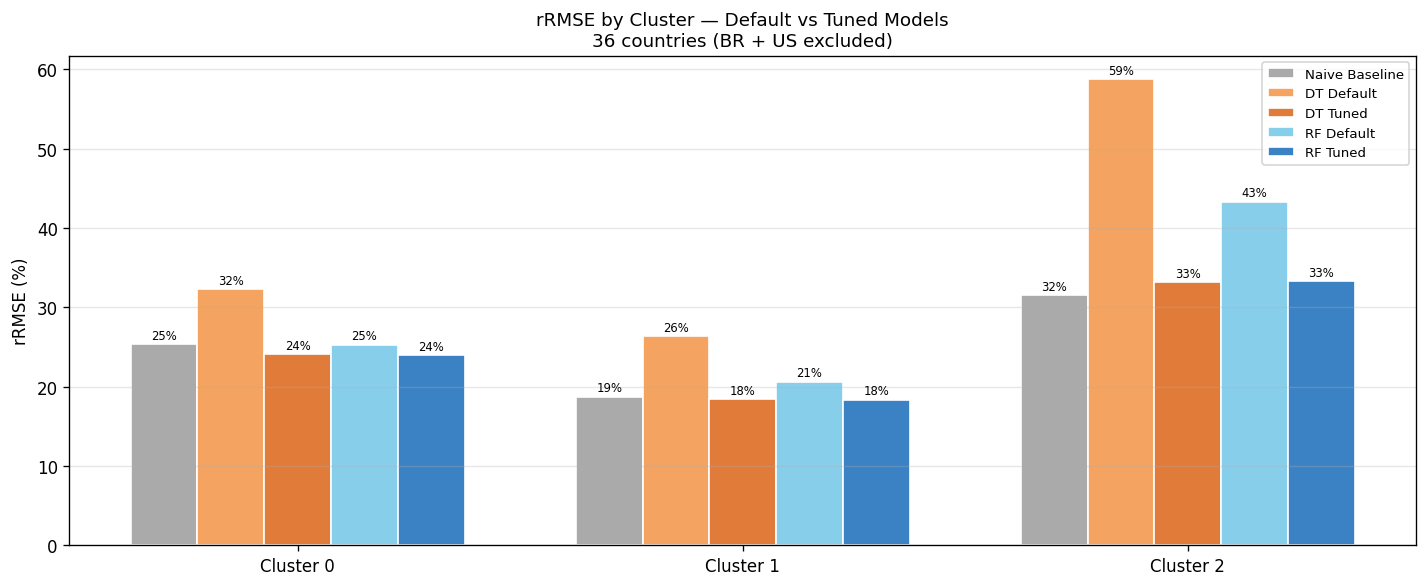

Saved: fig_model_comparison_tuned.png


In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(CLUSTERS))
width = 0.15

models = [
    (naive_df,           'Naive Baseline', '#aaaaaa'),
    (dt_default_results, 'DT Default',     '#f4a460'),
    (dt_tuned_results,   'DT Tuned',       '#e07b39'),
    (rf_default_results, 'RF Default',     '#87ceeb'),
    (rf_tuned_results,   'RF Tuned',       '#3b82c4'),
]

offsets = [-2, -1, 0, 1, 2]
for (res_df, label, color), offset in zip(models, offsets):
    bars = ax.bar(x + offset * width, res_df['rRMSE (%)'], width,
                  label=label, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.0f}%',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {c}' for c in CLUSTERS])
ax.set_ylabel('rRMSE (%)')
ax.set_title('rRMSE by Cluster — Default vs Tuned Models\n'
             '36 countries (BR + US excluded)', fontsize=11)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./fig_model_comparison_tuned.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_model_comparison_tuned.png')

---
## 7. Summary

In [17]:
print('HYPERPARAMETER TUNING SUMMARY')
print()
print(f'Best Decision Tree params: {dt_grid.best_params_}')
print(f'Best Random Forest params: {rf_grid.best_params_}')
print()
print('Key findings:')
for i, c in enumerate(CLUSTERS):
    naive_r  = naive_df.iloc[i]['rRMSE (%)']
    dt_tun_r = dt_tuned_results.iloc[i]['rRMSE (%)']
    rf_tun_r = rf_tuned_results.iloc[i]['rRMSE (%)']
    best_r   = min(dt_tun_r, rf_tun_r)
    best_model = 'DT tuned' if dt_tun_r <= rf_tun_r else 'RF tuned'
    diff = naive_r - best_r
    direction = f'improvement of {diff:.1f}pp over naive' if diff > 0 else f'STILL {-diff:.1f}pp worse than naive'
    print(f'  Cluster {c}: naive={naive_r:.1f}% | best={best_r:.1f}% ({best_model}) | {direction}')
print()
print('Next step: Step 8 — statistical comparison + interpretability')

HYPERPARAMETER TUNING SUMMARY

Best Decision Tree params: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 5}
Best Random Forest params: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 200}

Key findings:
  Cluster 0: naive=25.3% | best=23.9% (RF tuned) | improvement of 1.4pp over naive
  Cluster 1: naive=18.7% | best=18.4% (RF tuned) | improvement of 0.4pp over naive
  Cluster 2: naive=31.6% | best=33.1% (DT tuned) | STILL 1.6pp worse than naive

Next step: Step 8 — statistical comparison + interpretability
